In [91]:
import pandas as pd 
import numpy as np
from pandas.api.types import CategoricalDtype

In [92]:
filepath="Dataset.csv"
df=pd.read_csv(filepath,index_col=False)

In [93]:
df

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,No,24,Venmo,Weekly


In [94]:
df.shape

(3900, 18)

In [95]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [96]:
df['Frequency of Purchases'] = df['Frequency of Purchases'].str.strip()
df['Season'] = df['Season'].str.strip()
print("Cleaned Frequencies:", df['Frequency of Purchases'].unique())

Cleaned Frequencies: ['Fortnightly' 'Weekly' 'Annually' 'Quarterly' 'Bi-Weekly' 'Monthly'
 'Every 3 Months']


In [97]:
null_ratings = df[df['Review Rating'].isnull()]
null_ratings

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
38,39,29,Male,Dress,Clothing,37,Florida,M,Red,Winter,NaN,Yes,2-Day Shipping,Yes,Yes,44,Venmo,Every 3 Months
50,51,49,Male,Blouse,Clothing,28,Maryland,M,Red,Spring,NaN,Yes,Store Pickup,Yes,Yes,39,Debit Card,Bi-Weekly
80,81,19,Male,Sandals,Footwear,72,New York,XL,Blue,Summer,NaN,Yes,Store Pickup,Yes,Yes,24,Credit Card,Every 3 Months
96,97,32,Male,Gloves,Accessories,73,Delaware,S,Gold,Spring,NaN,Yes,Express,Yes,Yes,43,Venmo,Every 3 Months
262,263,37,Male,Pants,Clothing,40,Hawaii,M,Teal,Summer,NaN,Yes,Next Day Air,Yes,Yes,6,Debit Card,Annually
330,331,46,Male,Sweater,Clothing,51,North Dakota,M,Beige,Winter,NaN,Yes,Express,Yes,Yes,43,Venmo,Bi-Weekly
356,357,56,Male,Pants,Clothing,80,Nevada,L,Black,Spring,NaN,Yes,Standard,Yes,Yes,27,Cash,Weekly
383,384,50,Male,Sunglasses,Accessories,77,West Virginia,S,Magenta,Fall,NaN,Yes,Standard,Yes,Yes,6,PayPal,Quarterly
419,420,53,Male,Shorts,Clothing,91,Utah,S,Teal,Winter,NaN,Yes,Free Shipping,Yes,Yes,14,Credit Card,Every 3 Months
442,443,29,Male,Sunglasses,Accessories,69,Michigan,M,Olive,Fall,NaN,Yes,Store Pickup,Yes,Yes,31,Credit Card,Quarterly


Empty review fields were replaced with the median review rating of the dataset. To account for customer purchasing behavior, a loyalty-based correction factor was introduced. Customers with more than 20 purchases were classified as frequent buyers and were assigned additional review points during imputation. This approach leverages both population-level review statistics and user-specific purchase frequency, thereby producing a more informed estimate of missing review values than conventional median imputation alone.

In [98]:
missing_mask = df['Review Rating'].isnull()

df['Review Rating'] = df.groupby(
    ['Category', 'Gender']
)['Review Rating'].transform(
    lambda x: x.fillna(x.median())
)

loyal_mask = missing_mask & (df['Previous Purchases'] >= 20)

bonus = np.log1p(df.loc[loyal_mask, 'Previous Purchases']) / np.log(51)

df.loc[loyal_mask, 'Review Rating'] = np.clip(
    df.loc[loyal_mask, 'Review Rating'] + 0.2 * bonus,
    2.5,
    5.0
)

ONE HOT ENCODING ON THESE COLUMNS

In [99]:
binary_columns = ['Discount Applied', 'Promo Code Used', 'Subscription Status']

for col in binary_columns:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

In [100]:
df.columns.unique()

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases'],
      dtype='object')

In [101]:
from pandas.api.types import CategoricalDtype
season_order = CategoricalDtype(
    categories=['Spring', 'Summer', 'Fall', 'Winter'], 
    ordered=True
)
df['Season'] = df['Season'].astype(season_order)

In [102]:
frequency_map = {
    "Weekly": 52,
    "Fortnightly": 26,
    "Bi-Weekly": 26,
    "Monthly": 12,
    "Every 3 Months": 4,
    "Quarterly": 4,
    "Annually": 1
}
df['purchases_per_year'] = df['Frequency of Purchases'].map(frequency_map)

Customer Lifetime Value (CLV) was estimated using three key factors: the amount spent by a customer, how frequently they make purchases, and their purchase history. To better represent customer loyalty, a logarithmic scaling function was applied to the number of previous purchases instead of using a simple linear scale. This was done because the increase in customer value is not always proportional to the number of purchases made. For example, the difference between a first-time buyer and a customer with five purchases is often more significant than the difference between customers with forty-five and fifty purchases. By using logarithmic scaling, loyal customers are rewarded while preventing extremely frequent buyers from having an excessive influence on the final CLV score. This results in a more balanced and realistic estimate of a customer's long-term value to the business.


In [103]:
history_score = (np.log1p(df['Previous Purchases']) /np.log1p(df['Previous Purchases'].max()))
frequency_score = (df['purchases_per_year'] /df['purchases_per_year'].max())

df['loyalty_factor'] = (0.4 * history_score +0.6 * frequency_score)
df['eltv'] = (np.log1p(df['Purchase Amount (USD)'])* df['purchases_per_year']* df['loyalty_factor'])
df['pdr'] = df['Promo Code Used']

In [104]:
avg_full = df[df['Discount Applied'] == 0].groupby('Category')['Purchase Amount (USD)'].mean()
avg_disc = df[df['Discount Applied'] == 1].groupby('Category')['Purchase Amount (USD)'].mean()

discount_premium = avg_full - avg_disc

df['discount_premium'] = df['Category'].map(discount_premium)

In [105]:
max_freq = df['purchases_per_year'].max()
df['satisfaction_index'] = (0.6 * (df['Review Rating']/5)+ 0.2 * (df['purchases_per_year']/max_freq)+ 0.2 * df['loyalty_factor'])

In [106]:
category_avg = df.groupby('Category')['Purchase Amount (USD)'].transform('mean')
df['category_affinity'] = (df['Purchase Amount (USD)'] /category_avg)

In [107]:
df['loyalty_tier'] = pd.qcut(df['Previous Purchases'],q=4,labels=['Bronze','Silver','Gold','Platinum'])

In [108]:
df['discount_dependency'] = df['Discount Applied'] * df['loyalty_factor'] * df['purchases_per_year']

In [109]:
"""here we do not have the timestamps for the purchase history so we are modifying popular scheme RFM (Recency, Frequecy and Monetary Value),
   here we are using history score using purchase history of respctive customers""" 

df['H_score'] = pd.qcut(df['Previous Purchases'], 5, labels=[1,2,3,4,5], duplicates='drop').astype(int)
df['F_score'] = pd.qcut(df['purchases_per_year'], 5, labels=False, duplicates='drop') + 1
df['M_score'] = pd.qcut(df['Purchase Amount (USD)'], 5, labels=False, duplicates='drop') + 1
df['rfm_score'] = df['H_score'] + df['F_score'] + df['M_score']

In [110]:
df

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,...,pdr,discount_premium,satisfaction_index,category_affinity,loyalty_tier,discount_dependency,H_score,F_score,M_score,rfm_score
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,...,1,0.471264,0.587100,0.882961,Silver,14.963014,2,2,3,7
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,...,1,0.471264,0.554353,1.066217,Bronze,10.705919,1,2,3,6
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,...,1,0.471264,0.756663,1.216153,Silver,48.012424,3,3,4,10
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,...,1,-2.719816,0.819597,1.493641,Platinum,51.895241,5,3,5,13
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,...,1,0.471264,0.400670,0.816322,Gold,0.364121,4,1,2,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,...,0,0.471264,0.895143,0.466470,Gold,0.000000,4,3,1,8
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,...,0,2.399655,0.776050,0.818868,Platinum,0.000000,5,2,2,9
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,...,0,2.399655,0.438109,0.551482,Silver,0.000000,3,1,1,5
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,...,0,-2.719816,0.841494,1.277893,Silver,0.000000,3,3,4,10


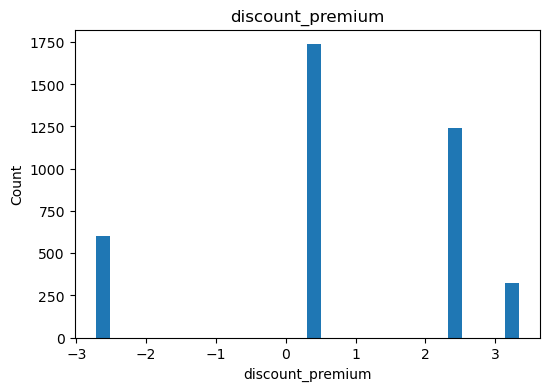

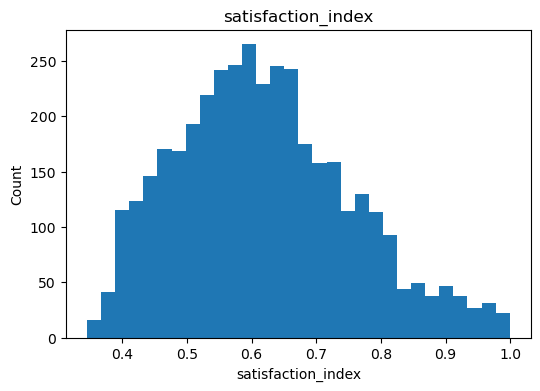

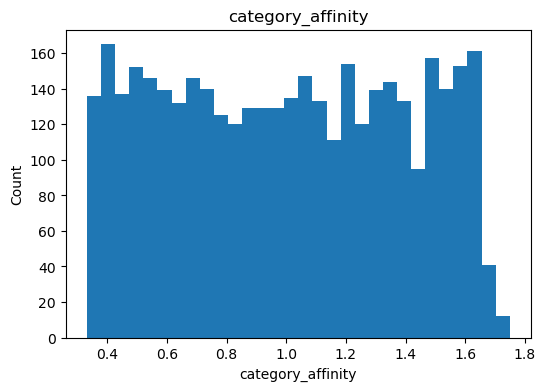

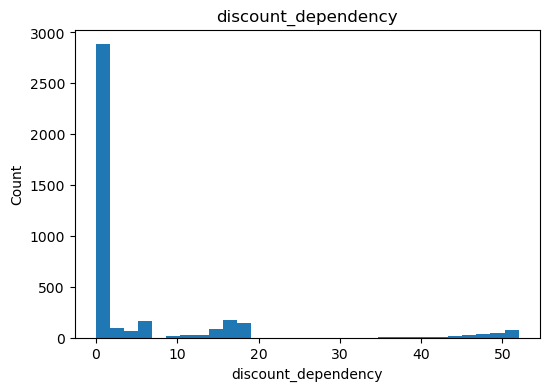

In [111]:
import matplotlib.pyplot as plt

features = [
    'discount_premium',
    'satisfaction_index',
    'category_affinity',
    'discount_dependency'
]

for col in features:
    plt.figure(figsize=(6,4))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

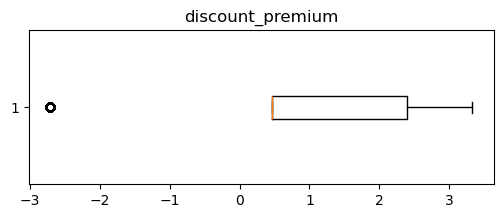

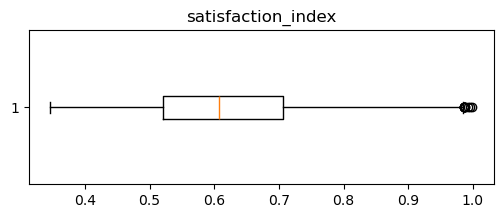

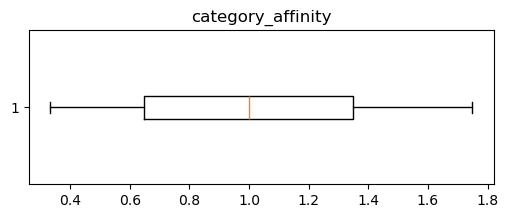

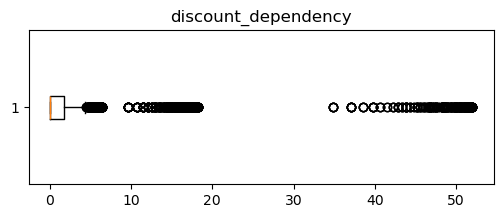

In [112]:

for col in [
    'discount_premium',
    'satisfaction_index',
    'category_affinity',
    'discount_dependency'
]:
    plt.figure(figsize=(6,2))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(col)
    plt.show()

C:\Users\Harshit\AppData\Local\Temp\ipykernel_29100\2872248866.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('loyalty_tier')['eltv'].mean().plot(


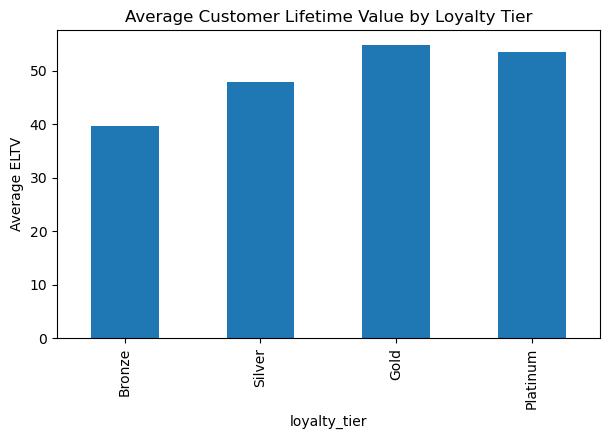

In [113]:
df.groupby('loyalty_tier')['eltv'].mean().plot(
    kind='bar',
    figsize=(7,4)
)

plt.ylabel('Average ELTV')
plt.title('Average Customer Lifetime Value by Loyalty Tier')
plt.show()

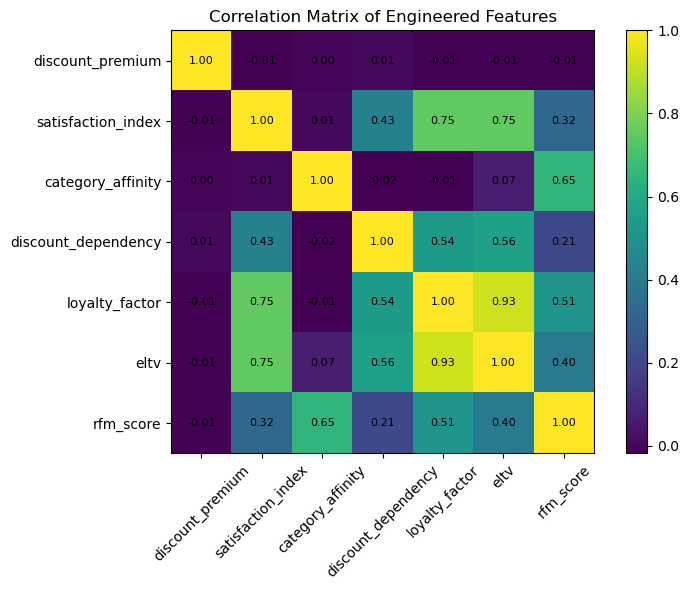

In [114]:
import matplotlib.pyplot as plt

features = [
    'discount_premium',
    'satisfaction_index',
    'category_affinity',
    'discount_dependency',
    'loyalty_factor',
    'eltv',
    'rfm_score'
]

corr = df[features].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr)
plt.colorbar()

plt.xticks(range(len(features)), features, rotation=45)
plt.yticks(range(len(features)), features)

for i in range(len(features)):
    for j in range(len(features)):
        plt.text(
            j,
            i,
            f"{corr.iloc[i,j]:.2f}",
            ha='center',
            va='center',
            fontsize=8
        )

plt.title("Correlation Matrix of Engineered Features")
plt.tight_layout()
plt.show()

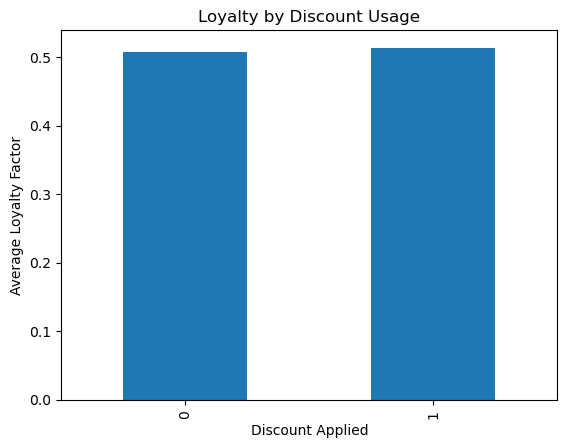

In [115]:
import matplotlib.pyplot as plt

discount_loyalty = df.groupby('Discount Applied')['loyalty_factor'].mean()

discount_loyalty.plot(kind='bar')
plt.ylabel('Average Loyalty Factor')
plt.title('Loyalty by Discount Usage')
plt.show()

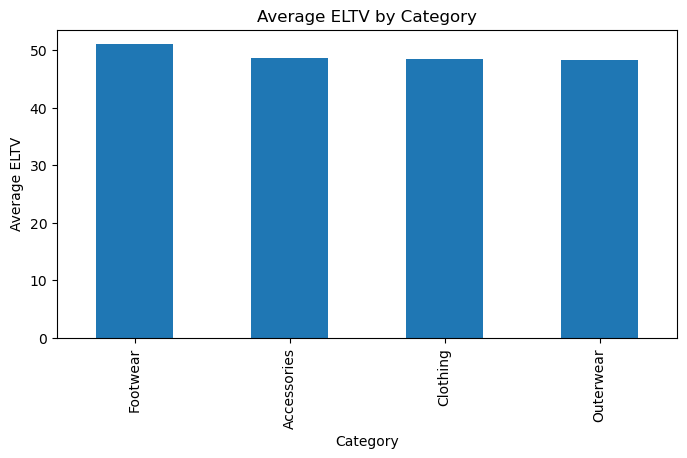

In [116]:
category_eltv = (
    df.groupby('Category')['eltv']
      .mean()
      .sort_values(ascending=False)
)

category_eltv.plot(
    kind='bar',
    figsize=(8,4)
)

plt.ylabel('Average ELTV')
plt.title('Average ELTV by Category')
plt.show()

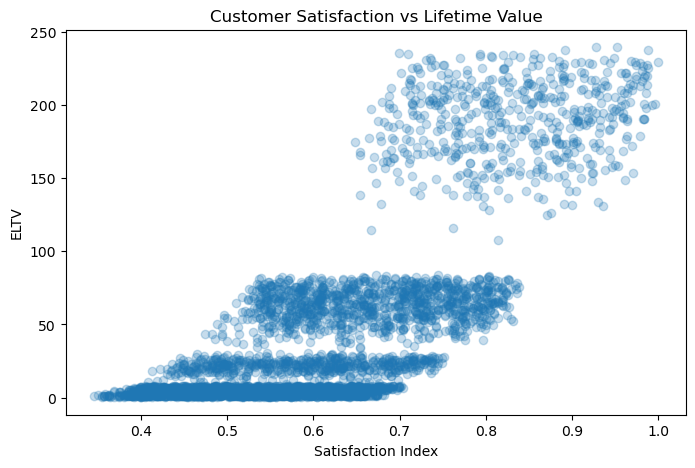

In [117]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['satisfaction_index'],
    df['eltv'],
    alpha=0.25
)

plt.xlabel('Satisfaction Index')
plt.ylabel('ELTV')
plt.title('Customer Satisfaction vs Lifetime Value')
plt.show()

C:\Users\Harshit\AppData\Local\Temp\ipykernel_29100\1105296972.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('loyalty_tier')['category_affinity'].mean().plot(


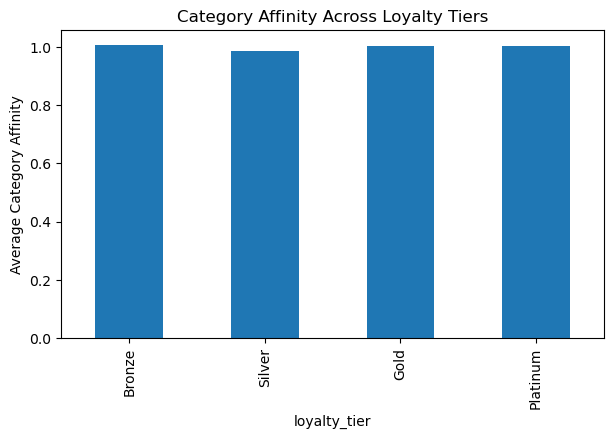

In [118]:
df.groupby('loyalty_tier')['category_affinity'].mean().plot(
    kind='bar',
    figsize=(7,4)
)

plt.ylabel('Average Category Affinity')
plt.title('Category Affinity Across Loyalty Tiers')
plt.show()

<Figure size 800x500 with 0 Axes>

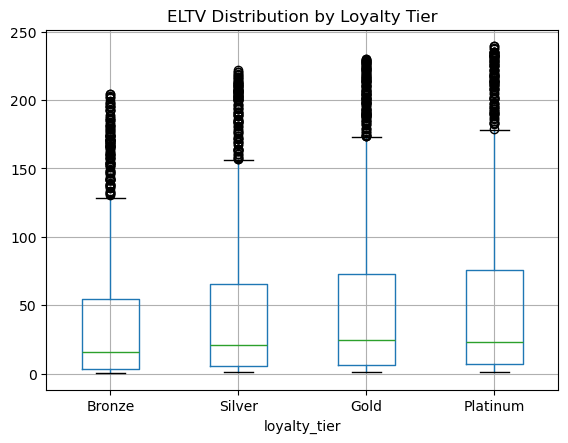

In [119]:
plt.figure(figsize=(8,5))

df.boxplot(
    column='eltv',
    by='loyalty_tier'
)

plt.title('ELTV Distribution by Loyalty Tier')
plt.suptitle('')
plt.show()

In [124]:
def assign_segment(row):
    score = row['rfm_score']
    promo = row['Promo Code Used']
    if score >= 11 and promo == 0:   return 'Champion'
    elif score >= 11 and promo == 1: return 'Loyal Promo-User'
    elif score >= 8  and promo == 0: return 'Organic Loyalist'
    elif score >= 8  and promo == 1: return 'Promo-Dependent'
    elif score >= 6:                 return 'Occasional Buyer'
    else:                            return 'At-Risk / One-Timer'

df['segment'] = df.apply(assign_segment, axis=1)
print(df['segment'].value_counts())

segment
Occasional Buyer       1236
Organic Loyalist        954
Promo-Dependent         696
At-Risk / One-Timer     625
Champion                209
Loyal Promo-User        180
Name: count, dtype: int64


In [126]:
df.drop(columns=['pdr', 'discount_dependency'], inplace=True)

In [127]:
df.to_csv("customers_enriched.csv", index=False)
print(df['segment'].value_counts())

segment
Occasional Buyer       1236
Organic Loyalist        954
Promo-Dependent         696
At-Risk / One-Timer     625
Champion                209
Loyal Promo-User        180
Name: count, dtype: int64
